
Processing: images/input_1.jpg


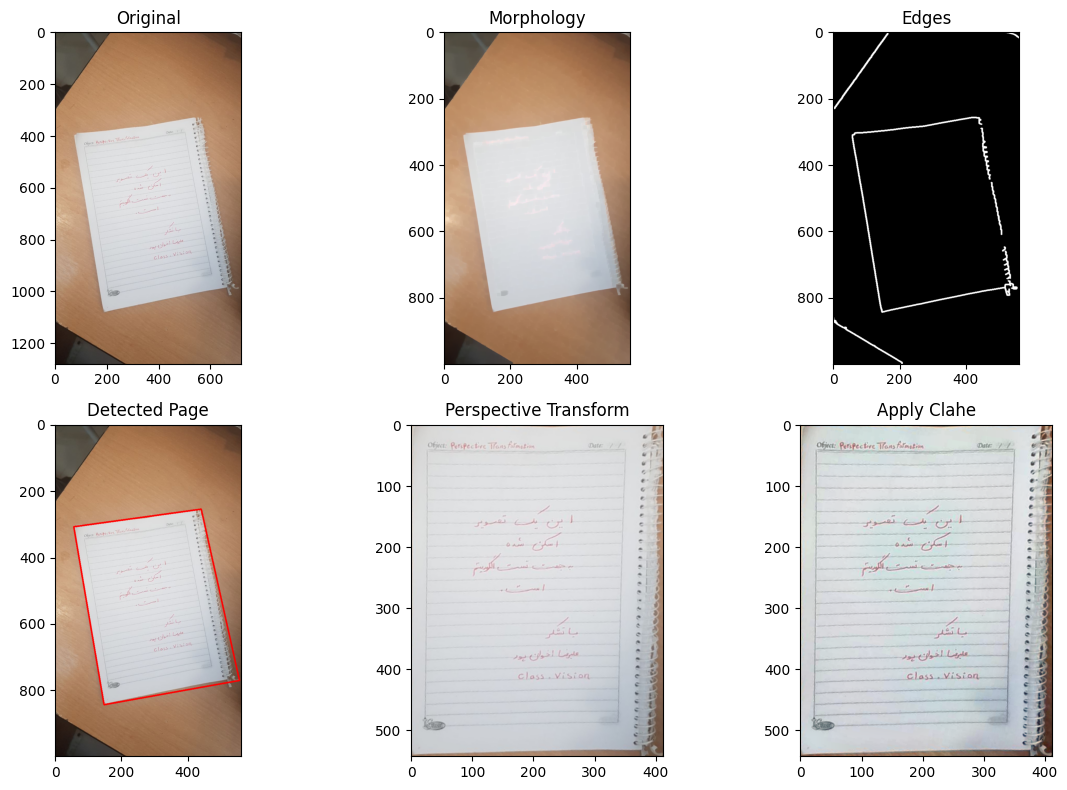


Processing: images/input_2.jpg


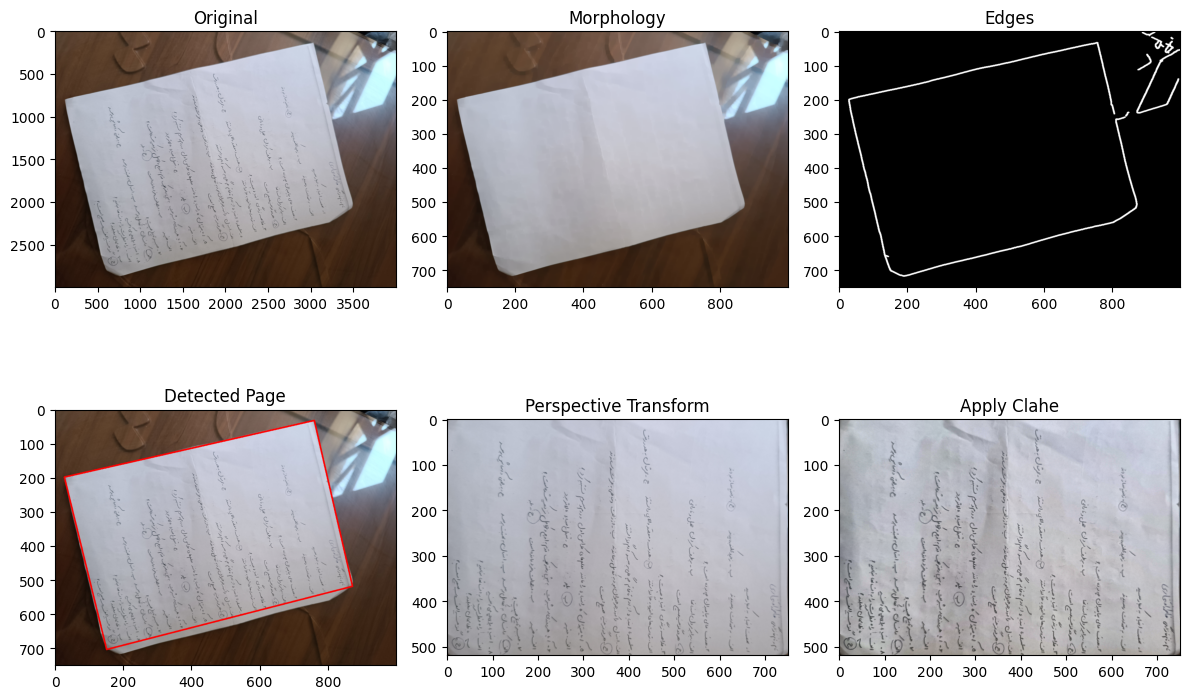


Processing: images/input_3.jpg


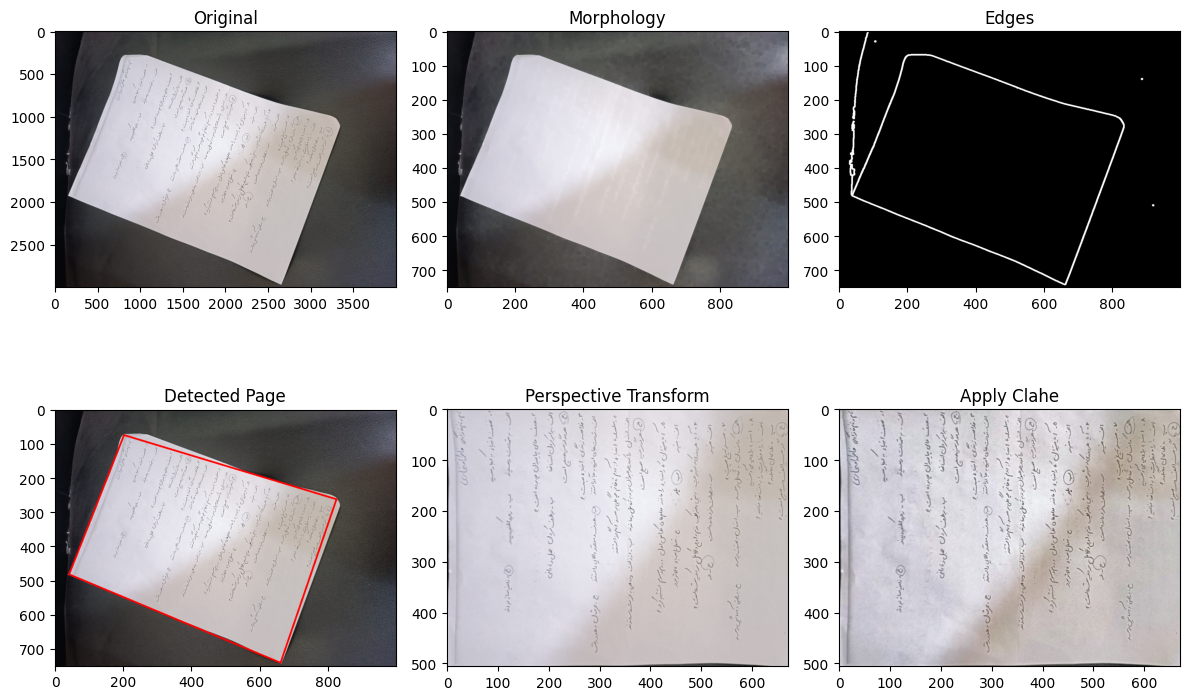


Processing: images/input_4.png


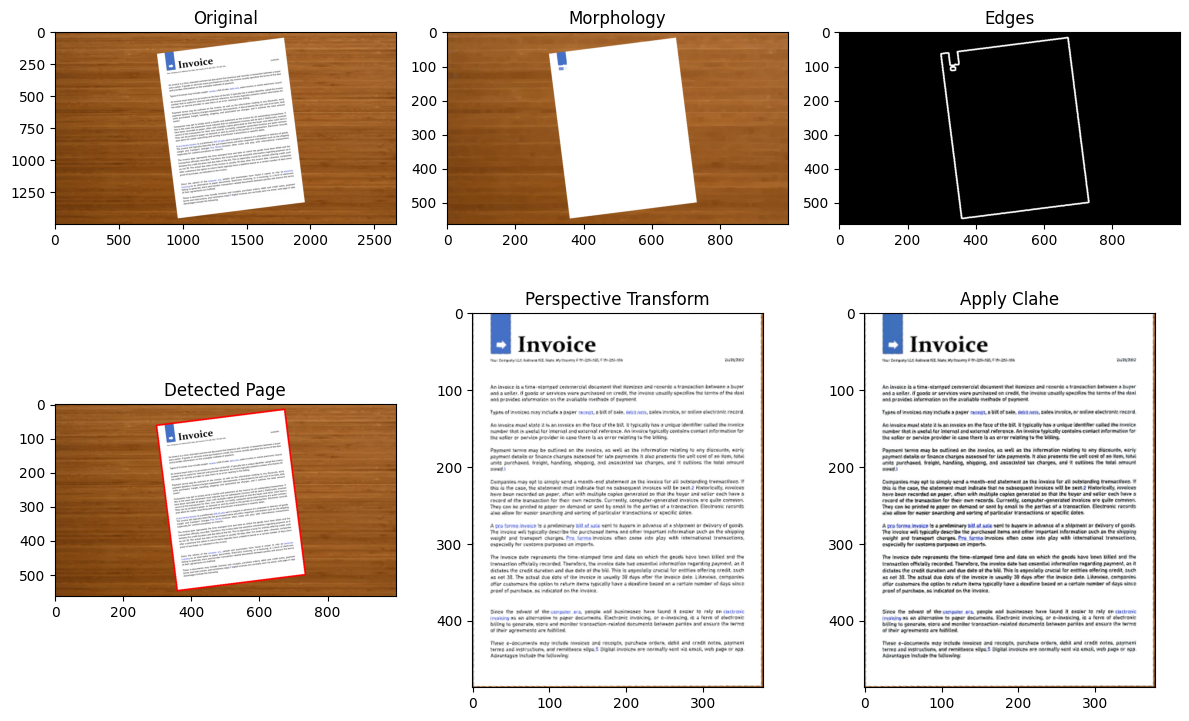

In [4]:
# This section is for finding documents with a dark background

# Import libraries
import numpy as np  # Import NumPy for numerical operations
import matplotlib.pyplot as plt  # Import Matplotlib for visualization
import cv2 as cv  # Import OpenCV for image processing

def read_image(image_path):
    # Read the image from the given file path
    return cv.imread(image_path)


def resize_if_needed(img, dim_limit=1000):
    # Get the maximum dimension of the image
    max_dim = np.max(img.shape[:2])

    # Check if resizing is needed
    if max_dim > dim_limit:
        # Calculate resize scale based on the dimension limit
        resize_scale = dim_limit / max_dim

        # Resize the image while preserving aspect ratio
        img = cv.resize(img, None, fx=resize_scale, fy=resize_scale)

    # Return the original or resized image
    return img


def apply_morphology(img):
    # Create a 5x5 kernel of ones for morphological operations
    kernel = np.ones((5, 5), np.uint8)

    # Apply morphological closing to reduce small gaps and noise
    close = cv.morphologyEx(img, cv.MORPH_CLOSE, kernel, iterations=2)

    # Return the morphologically processed image
    return close


def detect_edges(img):
    # Convert the image to grayscale
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Detect edges using the Canny edge detector
    canny = cv.Canny(gray, 100, 200)

    # Create an elliptical structuring element for dilation
    dilate_kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))

    # Dilate edges to make contours more connected
    canny = cv.dilate(canny, dilate_kernel)

    # Return the edge image
    return canny


def find_page_corners(canny):
    # Find all contours in the edge image
    contours, _ = cv.findContours(canny, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)

    # Initialize page corners as not found
    page_corners = None

    # Iterate through all detected contours
    for contour in contours:
        # Compute contour area
        area = cv.contourArea(contour)

        # Ignore very small contours
        if area < 5000:
            continue

        # Compute the convex hull of the contour
        hull = cv.convexHull(contour)

        # Approximate the hull with fewer points
        epsilon = 0.02 * cv.arcLength(hull, True)
        approx = cv.approxPolyDP(hull, epsilon, True)

        # Keep the largest contour approximated to 4 points
        if len(approx) == 4:
            page_corners = approx

    # Return the detected page corners
    return page_corners


def draw_detected_page(img, page_corners):
    # Create a copy of the input image for visualization
    img_result = img.copy()

    # Draw the detected page boundary if corners were found
    if page_corners is not None:
        # Reshape points to match OpenCV polyline format
        pts = page_corners.reshape((-1, 1, 2))

        # Draw the page contour in red
        cv.polylines(img_result, [pts], True, (0, 0, 255), 3)

    # Return the image with the detected page drawn
    return img_result


def order_page_points(page_corners):
    # Reshape corners into a 4x2 array
    p = page_corners.reshape(4, 2)

    # Compute the sum of x and y coordinates
    s = p.sum(axis=1)

    # Compute the difference between x and y coordinates
    diff = np.diff(p, axis=1)

    # Top-left point has the smallest sum
    tl = p[np.argmin(s)]

    # Bottom-right point has the largest sum
    br = p[np.argmax(s)]

    # Top-right point has the smallest difference
    tr = p[np.argmin(diff)]

    # Bottom-left point has the largest difference
    bl = p[np.argmax(diff)]

    # Return ordered points
    return tl, tr, br, bl


def perspective_transform(img, page_corners):
    # Order the page corner points
    tl, tr, br, bl = order_page_points(page_corners)

    # Create the source points array as float32
    src = np.float32([tl, tr, br, bl])

    # Compute the target width using the larger of top and bottom edges
    width = int(max(np.linalg.norm(br - bl), np.linalg.norm(tr - tl)))

    # Compute the target height using the larger of left and right edges
    height = int(max(np.linalg.norm(tr - br), np.linalg.norm(tl - bl)))

    # Create destination points for the warped image
    dst = np.float32([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]])

    # Compute perspective transform matrix
    matrix = cv.getPerspectiveTransform(src, dst)

    # Apply perspective warp to obtain the top-down page view
    warped = cv.warpPerspective(img, matrix, (width, height))

    # Return the warped image
    return warped


def apply_clahe_to_color_image(img):
    # Split the color image into separate channels
    channels = cv.split(img)

    # Create a CLAHE object for adaptive contrast enhancement
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    # Initialize a list to hold equalized channels
    equalized_channels = []

    # Apply CLAHE to each channel separately
    for channel in channels:
        # Enhance local contrast in the current channel
        equalized_channel = clahe.apply(channel)

        # Store the processed channel
        equalized_channels.append(equalized_channel)

    # Merge the processed channels back into a color image
    equalized_img = cv.merge(equalized_channels)

    # Return the contrast-enhanced image
    return equalized_img


def show_results(img_original, close, canny, img_result, warped, equalized_img):
    # Display images
    plt.figure(figsize=(12, 8))
    plt.subplot(231); plt.imshow(cv.cvtColor(img_original, cv.COLOR_BGR2RGB)); plt.title("Original")
    plt.subplot(232); plt.imshow(cv.cvtColor(close, cv.COLOR_BGR2RGB)); plt.title("Morphology")
    plt.subplot(233); plt.imshow(canny, cmap="gray"); plt.title("Edges")
    plt.subplot(234); plt.imshow(cv.cvtColor(img_result, cv.COLOR_BGR2RGB)); plt.title("Detected Page")
    plt.subplot(235); plt.imshow(cv.cvtColor(warped, cv.COLOR_BGR2RGB)); plt.title("Perspective Transform")
    plt.subplot(236); plt.imshow(cv.cvtColor(equalized_img, cv.COLOR_BGR2RGB)); plt.title("Apply Clahe")
    plt.tight_layout()
    plt.show()


def detect_page(image_path, dim_limit=1000):
    # Read the original image from disk
    img_original = read_image(image_path)

    # Create a copy of original image
    img = img_original.copy()

    # Resize the image if it exceeds the dimension limit
    img = resize_if_needed(img, dim_limit)

    # Apply morphological preprocessing
    close = apply_morphology(img)

    # Detect edges from the preprocessed image
    canny = detect_edges(close)

    # Find the 4-corner page contour
    page_corners = find_page_corners(canny)

    # Draw the detected page on a copy of the image
    img_result = draw_detected_page(img, page_corners)

    # Initialize warped image as not available
    warped = None

    # Initialize CLAHE result as not available
    equalized_img = None

    # Continue only if page corners were detected
    if page_corners is not None:
        # Apply perspective transformation to obtain a top-down page view
        warped = perspective_transform(img, page_corners)

        # Apply CLAHE enhancement on the warped image
        equalized_img = apply_clahe_to_color_image(warped)

    # Display all processing steps and final results
    show_results(img_original, close, canny, img_result, warped, equalized_img)


# Define the list of input image paths
images = [
    "images/input_1.jpg",
    "images/input_2.jpg",
    "images/input_3.jpg",
    "images/input_4.png",
]

# Process each image one by one
for image_path in images:
    # Print the current image path being processed
    print(f"\nProcessing: {image_path}")

    # Run page detection on the current image
    detect_page(image_path)


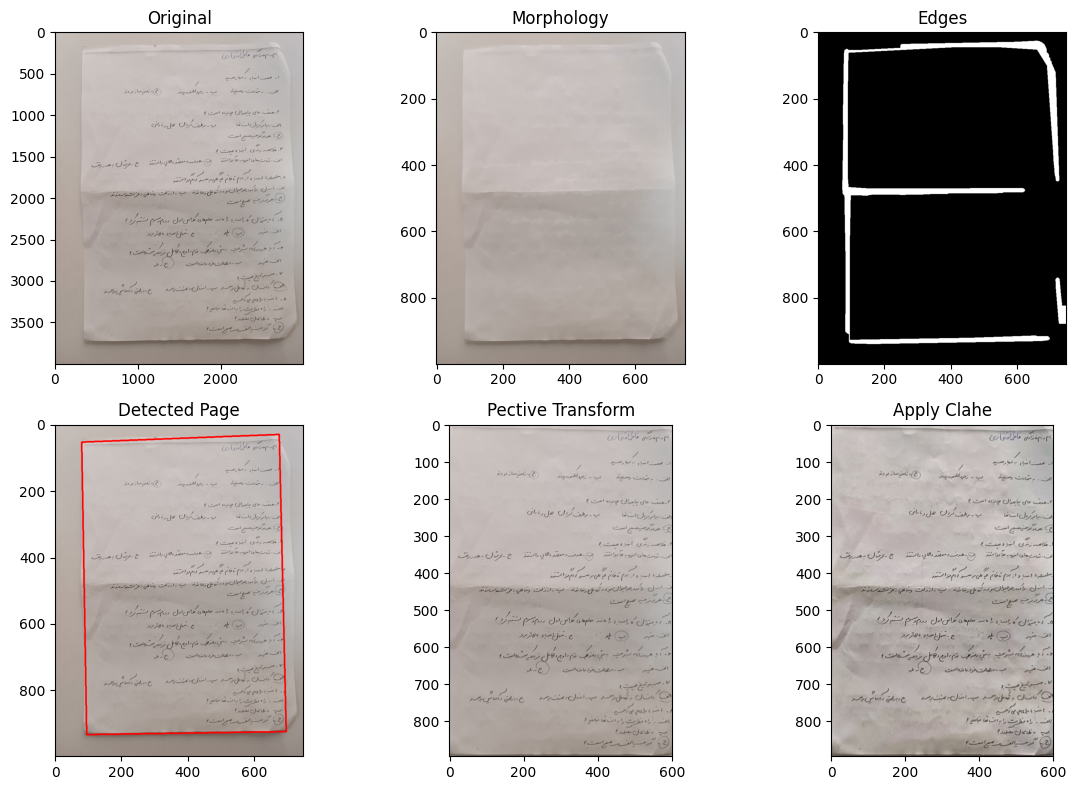

In [5]:
# This section is for finding documents with a light background

# Import libraries
import numpy as np 
import matplotlib.pyplot as plt
import cv2 as cv

def read_image(image_path):
    return cv.imread(image_path)


def resize_if_needed(img, dim_limit=1000):
    max_dim = np.max(img.shape[:2])
    if max_dim > dim_limit:
        resize_scale = dim_limit / max_dim
        img = cv.resize(img, None, fx=resize_scale, fy=resize_scale)
    return img


def apply_morphology(img):
    kernel = np.ones((5, 5), np.uint8)
    close = cv.morphologyEx(img, cv.MORPH_CLOSE, kernel, iterations=2)
    return close


def detect_edges(img, canny_thresh1=100, canny_thresh2=200, dilate_ksize=(5, 5)):
    # Convert the image to grayscale
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    # Detect edges using the Canny edge detector
    canny = cv.Canny(gray, canny_thresh1, canny_thresh2)
    # Create a structuring element for dilation
    dilate_kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, dilate_ksize)
    # Dilate edges to make contours more connected
    canny = cv.dilate(canny, dilate_kernel)
    return canny


def find_page_corners(canny):
    contours, _ = cv.findContours(canny, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
    page_corners = None
    for contour in contours:
        area = cv.contourArea(contour)
        if area < 5000:
            continue
        hull = cv.convexHull(contour)
        epsilon = 0.02 * cv.arcLength(hull, True)
        approx = cv.approxPolyDP(hull, epsilon, True)
        if len(approx) == 4:
            page_corners = approx
    return page_corners


def draw_detected_page(img, page_corners):
    img_result = img.copy()
    if page_corners is not None:
        pts = page_corners.reshape((-1, 1, 2))
        cv.polylines(img_result, [pts], True, (0, 0, 255), 3)
    return img_result


def order_page_points(page_corners):
    p = page_corners.reshape(4, 2)
    s = p.sum(axis=1)
    diff = np.diff(p, axis=1)
    tl = p[np.argmin(s)]
    br = p[np.argmax(s)]
    tr = p[np.argmin(diff)]
    bl = p[np.argmax(diff)]
    return tl, tr, br, bl


def perspective_transform(img, page_corners):
    tl, tr, br, bl = order_page_points(page_corners)
    src = np.float32([tl, tr, br, bl])
    width = int(max(np.linalg.norm(br - bl), np.linalg.norm(tr - tl)))
    height = int(max(np.linalg.norm(tr - br), np.linalg.norm(tl - bl)))
    dst = np.float32([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]])
    matrix = cv.getPerspectiveTransform(src, dst)
    warped = cv.warpPerspective(img, matrix, (width, height))
    return warped


def apply_clahe_to_color_image(img):
    channels = cv.split(img)
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    equalized_channels = []
    for channel in channels:
        equalized_channel = clahe.apply(channel)
        equalized_channels.append(equalized_channel)
    equalized_img = cv.merge(equalized_channels)
    return equalized_img


def show_results(img_original, close, canny, img_result, warped, equalized_img):
    plt.figure(figsize=(12, 8))
    plt.subplot(231); plt.imshow(cv.cvtColor(img_original, cv.COLOR_BGR2RGB)); plt.title("Original")
    plt.subplot(232); plt.imshow(cv.cvtColor(close, cv.COLOR_BGR2RGB)); plt.title("Morphology")
    plt.subplot(233); plt.imshow(canny, cmap="gray"); plt.title("Edges")
    plt.subplot(234); plt.imshow(cv.cvtColor(img_result, cv.COLOR_BGR2RGB)); plt.title("Detected Page")
    plt.subplot(235); plt.imshow(cv.cvtColor(warped, cv.COLOR_BGR2RGB)); plt.title("Pective Transform")
    plt.subplot(236); plt.imshow(cv.cvtColor(equalized_img, cv.COLOR_BGR2RGB)); plt.title("Apply Clahe")
    plt.tight_layout()
    plt.show()


def build_line_mask(edge_img):
    lines = cv.HoughLinesP(edge_img, 3, np.pi / 180, 50, minLineLength=20, maxLineGap=300)
    line_mask = np.zeros_like(edge_img)
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv.line(line_mask, (x1, y1), (x2, y2), 255, 5)
    line_mask = cv.morphologyEx(line_mask, cv.MORPH_CLOSE, cv.getStructuringElement(cv.MORPH_RECT, (15, 15)), iterations=2)
    return line_mask


def detect_page_light_background(image_path, dim_limit=1000):
    img_original = read_image(image_path)
    img = img_original.copy()
    img = resize_if_needed(img, dim_limit)
    close = apply_morphology(img)

    canny = detect_edges(close, canny_thresh1=50, canny_thresh2=70, dilate_ksize=(7, 7))
    canny = cv.morphologyEx(canny, cv.MORPH_CLOSE, cv.getStructuringElement(cv.MORPH_RECT, (20, 20)), iterations=2)

    line_mask = build_line_mask(canny)
    page_corners = find_page_corners(line_mask)
    img_result = draw_detected_page(img, page_corners)

    warped = None
    equalized_img = None
    if page_corners is not None:
        warped = perspective_transform(img, page_corners)
        equalized_img = apply_clahe_to_color_image(warped)

    show_results(img_original, close, line_mask, img_result, warped, equalized_img)


# Run page detection on the light-background sample image
detect_page_light_background("images/input_5.jpg")